# Heart Disease Prediction — Kaggle Playground S6E2

**Goal:** Predict the presence or absence of heart disease from clinical features.  
**Metric:** ROC-AUC (higher is better, max = 1.0)  
**Approach:** First-principles learning — understand why before how.

---

## How to read this notebook

Every section starts with an explanation block (like this one) that answers:  
- **What** are we doing?  
- **Why** does it matter?  
- **What should we expect** to find?

Then comes the code. Read the explanation first, then run the code, then think about what you see.

---
# Phase 1 — Exploratory Data Analysis (EDA)

**First principle:** Never touch a model before you understand your data.  

EDA is not optional cleanup — it is *the most important step*. It tells you:  
1. Are there data quality issues? (missing values, outliers, wrong types)  
2. What does the target distribution look like? (balanced? skewed?)  
3. Which features are informative? (do they vary with the target?)  
4. Are features correlated with each other? (multicollinearity)  

Everything you find here shapes your modelling decisions.

In [9]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

print('Libraries loaded.')

Libraries loaded.


## 1.1 — Load the Data

Always start by just *looking* at the raw data.  
Check: shape, column names, dtypes, and the first few rows.

In [10]:
DATA_DIR = 'Dataset/'

train = pd.read_csv(DATA_DIR + 'train.csv')
test  = pd.read_csv(DATA_DIR + 'test.csv')
sub   = pd.read_csv(DATA_DIR + 'sample_submission.csv')

print(f'Train shape : {train.shape}')
print(f'Test shape  : {test.shape}')
print(f'Submission  : {sub.shape}')

train.head()

Train shape : (630000, 15)
Test shape  : (270000, 14)
Submission  : (270000, 2)


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.600,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.000,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.000,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.000,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.800,2,3,3,Presence


In [11]:
# Data types and memory usage
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Heart Disease  

## 1.2 — Missing Values

**Why this matters:** Most ML algorithms cannot handle NaN values — they'll error out or silently produce garbage predictions.  
We need to know *how many* values are missing and *which features* have them before deciding how to handle them.

Strategies (we'll choose based on what we find):  
- **Drop rows** — only if very few rows are affected  
- **Fill with median/mode** — simple and usually fine for tree-based models  
- **Fill with model** — overkill for most cases

In [12]:
missing_train = train.isnull().sum()
missing_test  = test.isnull().sum()

missing = pd.DataFrame({
    'Train Missing'  : missing_train,
    'Train %'        : (missing_train / len(train) * 100).round(2),
    'Test Missing'   : missing_test,
    'Test %'         : (missing_test  / len(test)  * 100).round(2),
})

missing[missing['Train Missing'] > 0]

,Train Missing,Train %,Test Missing,Test %


In [13]:
# Summary statistics — check for unusual min/max values
train.describe()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000
mean,314999.500,54.137,0.715,3.313,130.497,245.012,0.080,0.982,152.817,0.274,0.716,1.456,0.451,4.619
std,181865.479,8.256,0.452,0.852,14.976,33.682,0.271,0.999,19.113,0.446,0.948,0.545,0.799,1.950
min,0.000,29.000,0.000,1.000,94.000,126.000,0.000,0.000,71.000,0.000,0.000,1.000,0.000,3.000
25%,157499.750,48.000,0.000,3.000,120.000,223.000,0.000,0.000,142.000,0.000,0.000,1.000,0.000,3.000
50%,314999.500,54.000,1.000,4.000,130.000,243.000,0.000,0.000,157.000,0.000,0.100,1.000,0.000,3.000
75%,472499.250,60.000,1.000,4.000,140.000,269.000,0.000,2.000,166.000,1.000,1.400,2.000,1.000,7.000
max,629999.000,77.000,1.000,4.000,200.000,564.000,1.000,2.000,202.000,1.000,6.200,3.000,3.000,7.000


## 1.3 — Target Distribution

**Why this matters:** If 95% of patients have "Absence" and only 5% have "Presence",  
a model that always predicts "Absence" would be 95% accurate — but completely useless.  

Class imbalance affects:  
- Which metric to use (ROC-AUC is robust to imbalance; accuracy is not)  
- Whether we need to oversample/undersample  
- How we interpret model outputs

Target distribution:
         Count  Percent
target                 
0       347546   55.200
1       282454   44.800


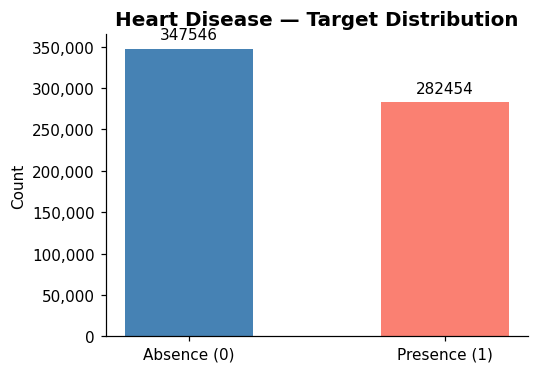

In [14]:
# Encode target: Presence=1, Absence=0
train['target'] = (train['Heart Disease'] == 'Presence').astype(int)

counts = train['target'].value_counts()
pct    = train['target'].value_counts(normalize=True) * 100

print('Target distribution:')
print(pd.DataFrame({'Count': counts, 'Percent': pct.round(1)}))

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(['Absence (0)', 'Presence (1)'], counts.sort_index(), color=['steelblue', 'salmon'], width=0.5)
ax.bar_label(ax.containers[0], fmt='%d', padding=4, fontsize=10)
ax.set_title('Heart Disease — Target Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 1.4 — Feature Reference

Before visualizing, let's understand what each feature *means* clinically.  
This matters because domain knowledge guides feature engineering decisions later.

| Feature | Type | Medical Meaning |
|---|---|---|
| Age | Continuous | Patient age in years — older = higher risk |
| Sex | Binary | 1 = Male, 0 = Female — men have higher risk at younger ages |
| Chest pain type | Categorical | 1=typical angina, 2=atypical, 3=non-anginal, 4=asymptomatic |
| BP | Continuous | Resting blood pressure (mmHg) — high BP is a risk factor |
| Cholesterol | Continuous | Serum cholesterol mg/dl — high levels clog arteries |
| FBS over 120 | Binary | Fasting blood sugar > 120 mg/dl — proxy for diabetes |
| EKG results | Categorical | Electrical heart activity: 0=normal, 1=ST-T wave abnormality, 2=LV hypertrophy |
| Max HR | Continuous | Max heart rate achieved — lower max HR can indicate disease |
| Exercise angina | Binary | Chest pain during exercise — strong signal |
| ST depression | Continuous | ECG drop during exercise — important cardiac marker |
| Slope of ST | Categorical | 1=upsloping (good), 2=flat, 3=downsloping (bad) |
| Number of vessels fluro | Continuous | 0–3 vessels visible on fluoroscopy — more = more disease |
| Thallium | Categorical | Blood flow scan: 3=normal, 6=fixed defect, 7=reversible defect |

## 1.5 — Feature Distributions

**What to look for:**  
- **Continuous features:** Are they roughly normal? Skewed? Any extreme outliers?  
- **Categorical features:** Are all expected values present? Any unexpected values?  
- **Do distributions shift between the 0 and 1 class?** This is the core signal.

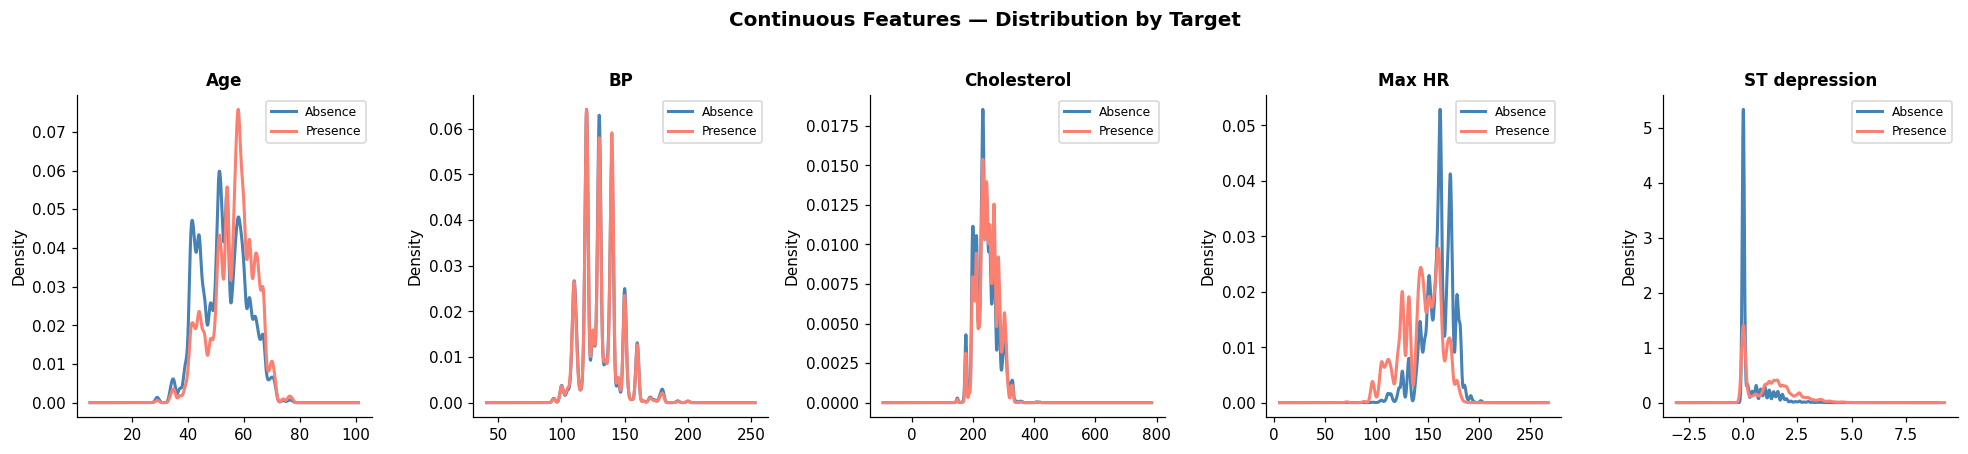

In [15]:
# Split feature names by type
CONTINUOUS   = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
CATEGORICAL  = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results',
                'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']

# Continuous features — KDE split by target
fig, axes = plt.subplots(1, len(CONTINUOUS), figsize=(18, 4))
for ax, col in zip(axes, CONTINUOUS):
    for val, label, color in [(0, 'Absence', 'steelblue'), (1, 'Presence', 'salmon')]:
        subset = train.loc[train['target'] == val, col]
        subset.plot.kde(ax=ax, label=label, color=color, linewidth=2)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=8)
fig.suptitle('Continuous Features — Distribution by Target', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

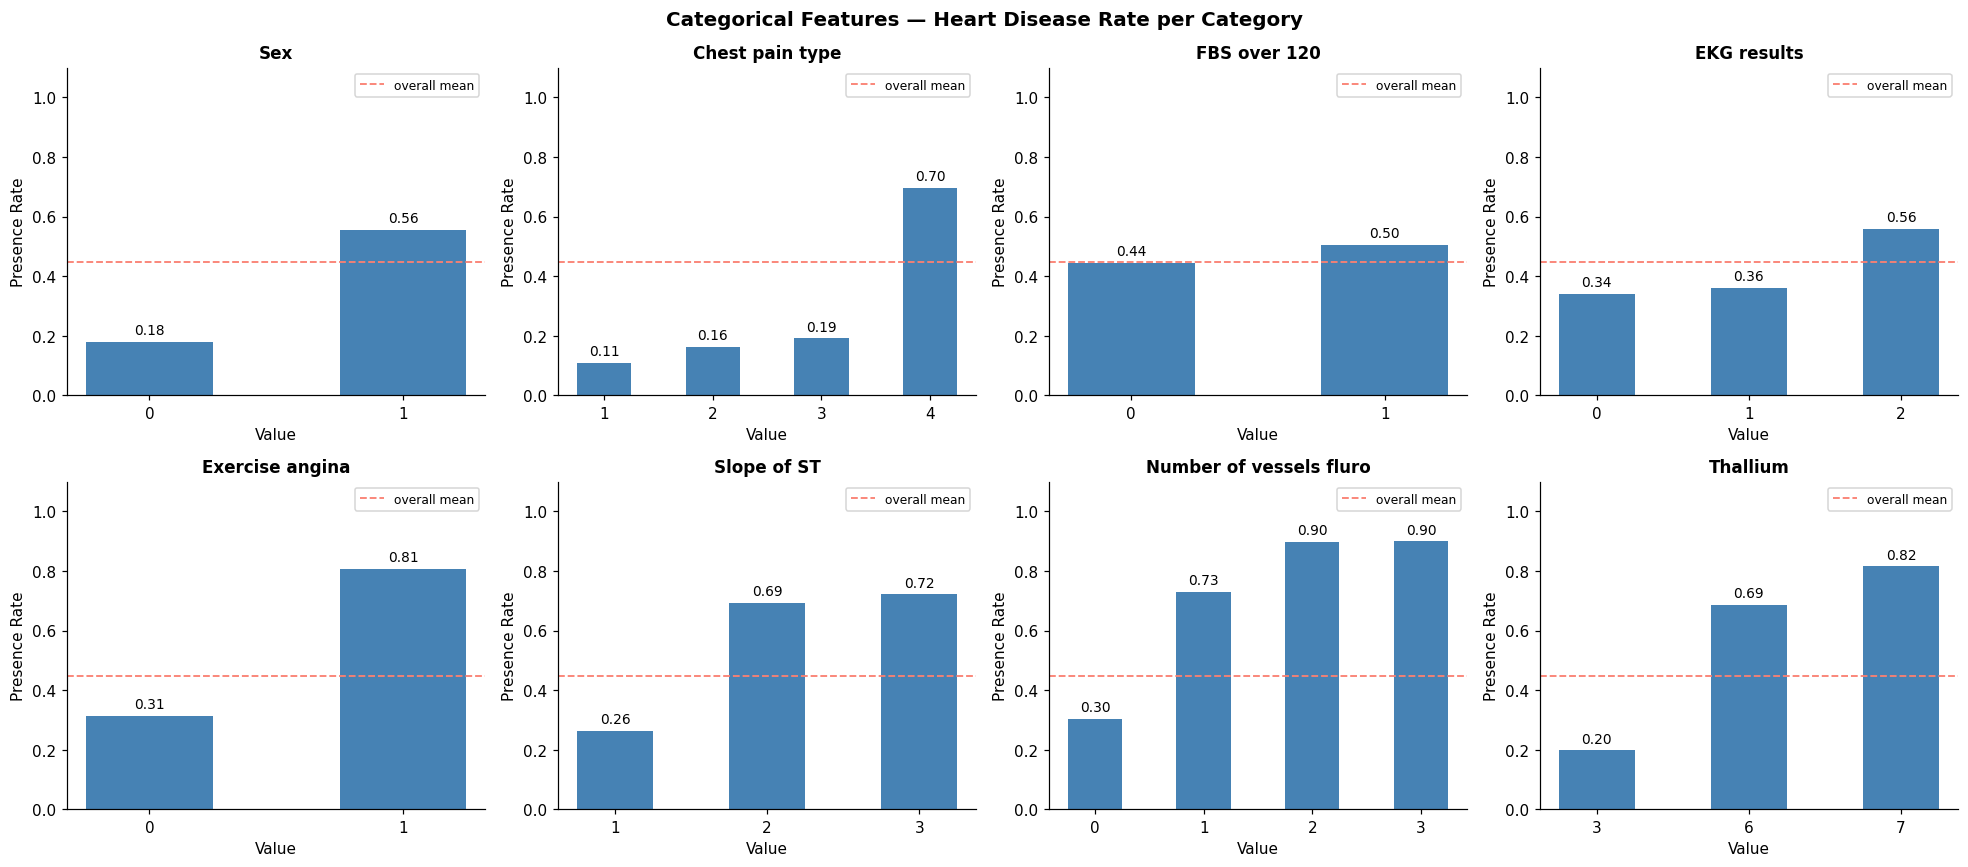

In [16]:
# Categorical features — Disease rate per category value
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, CATEGORICAL):
    rate = train.groupby(col)['target'].mean().sort_index()
    bars = ax.bar(rate.index.astype(str), rate.values, color='steelblue', width=0.5)
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Presence Rate')
    ax.set_xlabel('Value')
    ax.axhline(train['target'].mean(), color='salmon', linestyle='--', linewidth=1.2, label='overall mean')
    ax.legend(fontsize=8)

fig.suptitle('Categorical Features — Heart Disease Rate per Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 1.6 — Correlation Analysis

**Pearson correlation with target** tells us: for continuous features, which direction does the feature move as disease risk increases?  

Limitations to keep in mind:  
- Pearson only captures *linear* relationships — a feature can be important even with low correlation  
- Correlated features carry redundant information (but tree models handle this fine)  

**Point-biserial correlation** is the right term when one variable is binary — but numerically it equals Pearson, so we use `.corr()` directly.

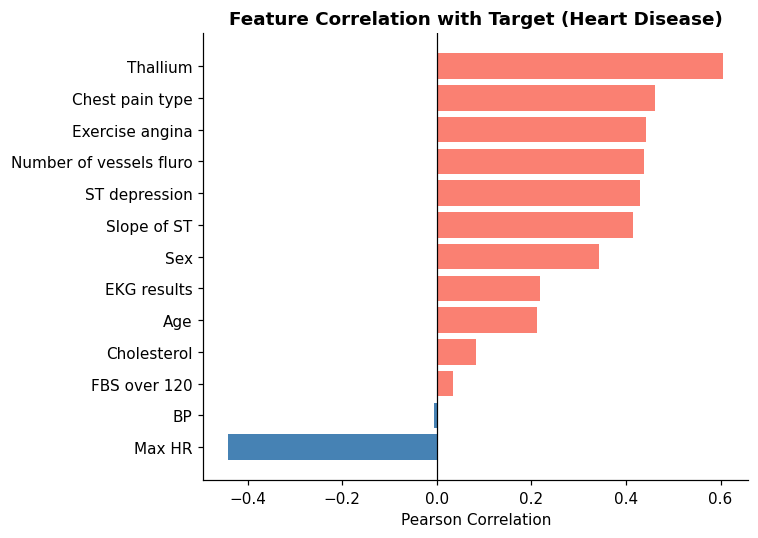


Top positive correlators (increase disease risk):
ST depression             0.431
Number of vessels fluro   0.439
Exercise angina           0.442
Chest pain type           0.461
Thallium                  0.606

Top negative correlators (decrease disease risk):
Max HR   -0.441
BP       -0.005


In [17]:
# Encode categoricals as integers for correlation
feature_cols = CONTINUOUS + CATEGORICAL
corr_with_target = train[feature_cols + ['target']].corr()['target'].drop('target').sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['salmon' if v > 0 else 'steelblue' for v in corr_with_target.values]
bars = ax.barh(corr_with_target.index, corr_with_target.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Target (Heart Disease)', fontsize=12, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print('\nTop positive correlators (increase disease risk):')
print(corr_with_target[corr_with_target > 0].tail(5).to_string())
print('\nTop negative correlators (decrease disease risk):')
print(corr_with_target[corr_with_target < 0].head(5).to_string())

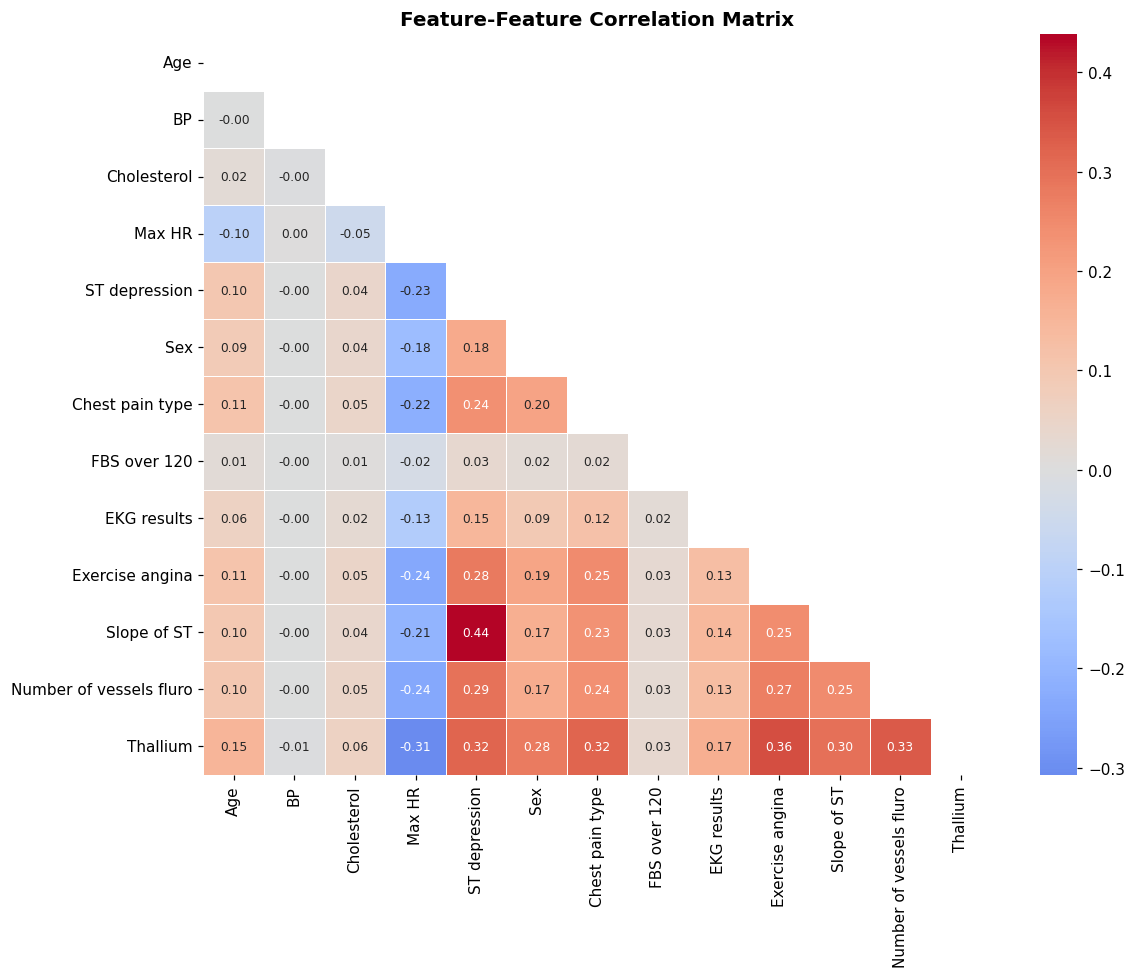

In [18]:
# Feature-feature correlation heatmap
# Why: if two features are highly correlated (e.g. > 0.8), they carry near-identical information.
# This doesn't hurt tree models but is important to know.

corr_matrix = train[feature_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # show lower triangle only
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Feature-Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 1.7 — Distribution Shift: Train vs Test

**Why this matters:** If the test data has a different distribution than train data, your model may not generalize well.  
This is called **covariate shift** — the inputs changed even if the underlying relationship didn't.

We check this by comparing the mean and std of each feature across train and test.

In [19]:
train_stats = train[feature_cols].agg(['mean', 'std']).T.rename(columns={'mean': 'train_mean', 'std': 'train_std'})
test_stats  = test[feature_cols].agg(['mean', 'std']).T.rename(columns={'mean': 'test_mean',  'std': 'test_std'})

shift = pd.concat([train_stats, test_stats], axis=1)
shift['mean_diff_%'] = ((shift['test_mean'] - shift['train_mean']) / shift['train_mean'].abs().clip(lower=1e-6) * 100).round(2)

shift.sort_values('mean_diff_%', key=abs, ascending=False)

,train_mean,train_std,test_mean,test_std,mean_diff_%
Number of vessels fluro,0.451,0.799,0.455,0.801,0.830
Exercise angina,0.274,0.446,0.275,0.446,0.340
EKG results,0.982,0.999,0.978,0.999,-0.320
ST depression,0.716,0.948,0.718,0.947,0.290
Slope of ST,1.456,0.545,1.459,0.546,0.240
Sex,0.715,0.452,0.716,0.451,0.220
FBS over 120,0.080,0.271,0.080,0.271,0.080
Chest pain type,3.313,0.852,3.315,0.852,0.070
Age,54.137,8.256,54.160,8.255,0.040
BP,130.497,14.976,130.555,15.008,0.040


## 1.8 — EDA Summary

Fill in after running the cells above.

**Class balance:**  
- *(e.g. roughly balanced / imbalanced at X%)*

**Missing values:**  
- *(e.g. none / feature X has Y% missing)*

**Strongest predictors (from correlation chart):**  
- Positive (increase risk): *...*  
- Negative (decrease risk): *...*

**Notable patterns:**  
- *(e.g. Chest pain type 4 = asymptomatic has highest disease rate, which is counterintuitive — investigate)*

**Distribution shift between train and test:**  
- *(e.g. minimal / feature X shows notable shift)*

**Decisions for modelling:**  
- [ ] Encode target as 0/1  
- [ ] Handle any missing values  
- [ ] All features are already numeric — no text encoding needed  
- [ ] *(anything else you discovered)*

---
# Phase 2 — Baseline Model (Logistic Regression)

*(Coming next)*